 **Fundamentos de imágenes digitales y
operaciones básicas**





Una imagen digital puede verse como una cuadrícula. Cada celda es un píxel con un valor (gris o color). Para procesar imágenes, interesa saber qué píxeles “están cerca” y cómo se agrupan.


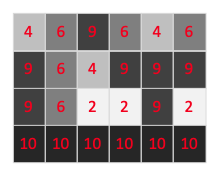

Muestreo (resolución): se pierden detalles y aparecen bloques/pixelación.


Cuantización (niveles de gris): se mantienen formas, pero el contraste se vuelve “a saltos” (banding).

cargar una imagen digital (caso 1)

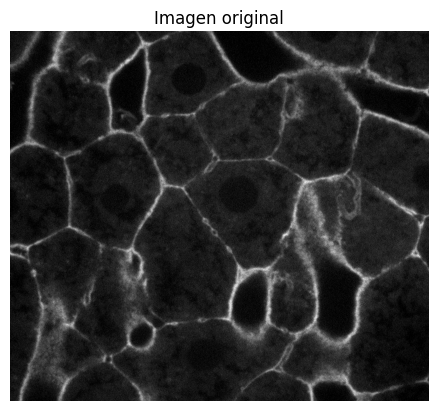

Shape: (694, 786) min: 0.0 max: 1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float

url = "https://github.com/hernanmorales-navarrete/EPIC_3/raw/main/Day_2/2D_image_cells_liver.tif"
img = io.imread(url)
img = img_as_float(img)

plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

print("Shape:", img.shape, "min:", img.min(), "max:", img.max())


Cargar imagen usando !wget

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

!wget https://www.dropbox.com/s/xro9nm69qxt3pl9/louvre.png

--2026-01-31 13:54:06--  https://www.dropbox.com/s/xro9nm69qxt3pl9/louvre.png
Resolving www.dropbox.com (www.dropbox.com)... 162.125.80.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.80.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/bi81xpu62dpeoog8pd1ef/louvre.png?rlkey=22w42w9zojyaxbnjt03a3n63z [following]
--2026-01-31 13:54:07--  https://www.dropbox.com/scl/fi/bi81xpu62dpeoog8pd1ef/louvre.png?rlkey=22w42w9zojyaxbnjt03a3n63z
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc28d19625207cfe1329135b4c03.dl.dropboxusercontent.com/cd/0/inline/C6BCx_WXyAQNybIypif0ep8LICq6DbTFXHP8UONd_iNW16-cfokuIZlLgapOWc2wqsNiLqCR5Qe4EhR2XjWHarTfZjGKHvRMwCn1_ILO_lhixOCYLZ5K2mKYMN3VPF3hxDo/file# [following]
--2026-01-31 13:54:07--  https://uc28d19625207cfe1329135b4c03.dl.dropboxusercontent.com/cd/0/inline/C6BCx_WXyAQNybIypif0ep8LIC

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
X = cv2.imread('pot.png',0)
print('size = ',X.shape)
plt.figure(figsize=(10,10))
plt.imshow(X,cmap='gray')
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
X = cv2.imread('onerice.png',0)
print('size = ',X.shape)
plt.figure(figsize=(10,10))
plt.imshow(X,cmap='gray')
plt.show()

Muestreo

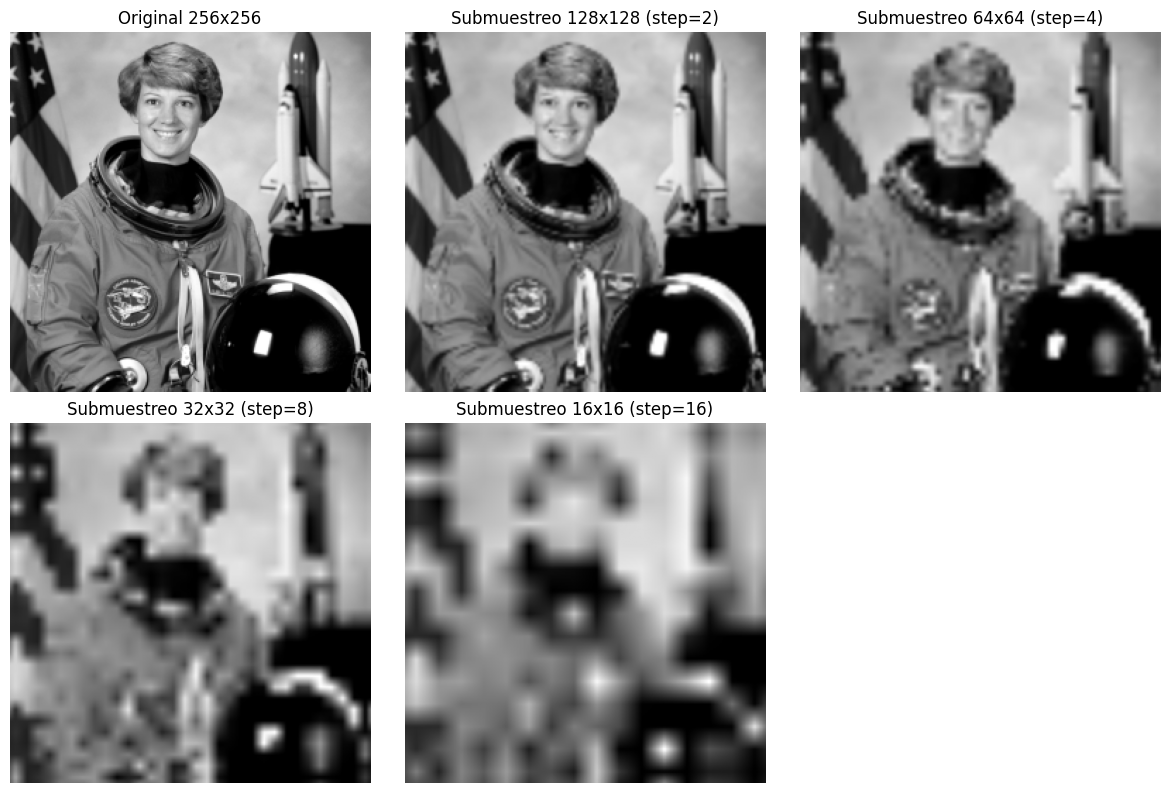

128 (128, 128)
64 (64, 64)
32 (32, 32)
16 (16, 16)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# Imagen base (gris, 256x256)
img = color.rgb2gray(data.astronaut())
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

def subsample_every_k(img, k):
    """
    Submuestreo por 'tomar un píxel sí y (k-1) no' en filas y columnas.
    k=2 -> 128x128 (1 sí, 1 no)
    k=4 -> 64x64
    k=8 -> 32x32
    k=16 -> 16x16
    """
    return img[::k, ::k]

# Submuestreos solicitados (desde 256x256)
factors = {128: 2, 64: 4, 32: 8, 16: 16}
samples = {}
ups = {}

for size, k in factors.items():
    low = subsample_every_k(img, k)  # toma un píxel sí y k-1 no
    samples[size] = low
    # Volver a 256x256 solo para visualizar el efecto "pixelado"
    ups[size] = resize(low, (256, 256), anti_aliasing=False)

# Mostrar resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 256x256")
plt.axis("off")

for i, size in enumerate([128, 64, 32, 16], start=2):
    plt.subplot(2, 3, i)
    plt.imshow(ups[size], cmap="gray")
    k = factors[size]
    plt.title(f"Submuestreo {size}x{size} (step={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()

# (Opcional) Ver tamaños reales submuestreados
for size in [128, 64, 32, 16]:
    print(size, samples[size].shape)


Cuantización

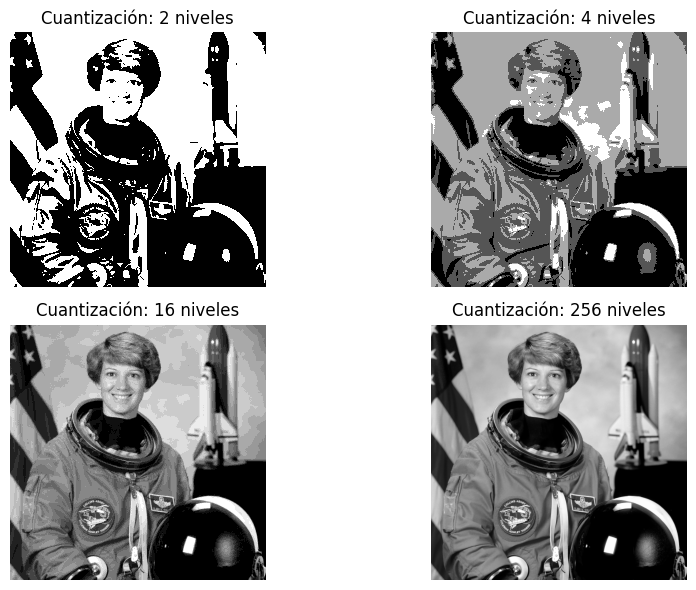

NameError: name 'resampled' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# Imagen base (gris, 256x256)
img = color.rgb2gray(data.astronaut())
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

# -----------------------------
# 2) CUANTIZACIÓN DE INTENSIDAD (niveles de gris)
# -----------------------------
# Idea: mantener la misma resolución, pero reducir el número de niveles (bits).
def quantize_levels(x, levels):
    # x en [0,1]
    xq = np.round(x * (levels - 1)) / (levels - 1)
    return xq

# Niveles típicos: 2 (1 bit), 4 (2 bits), 16 (4 bits), 256 (8 bits)
levels_list = [2, 4, 16, 256]
quantized = {L: quantize_levels(img, L) for L in levels_list}

plt.figure(figsize=(10, 6))
for i, L in enumerate(levels_list, start=1):
    plt.subplot(2, 2, i)
    plt.imshow(quantized[L], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Cuantización: {L} niveles")
    plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# 3) Comparación directa (misma imagen, dos "problemas" distintos)
# -----------------------------
# Muestreo bajo: pierde detalle espacial (pixelación).
# Cuantización baja: mantiene formas, pero aparecen "bandas" (saltos de intensidad).

low_sampling = resampled[16]       # 16x16 → 256 (muy pixelado)
low_quant    = quantized[4]        # 4 niveles (banding fuerte)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(low_sampling, cmap="gray")
plt.title("Bajo muestreo (16x16)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(low_quant, cmap="gray", vmin=0, vmax=1)
plt.title("Baja cuantización (4 niveles)")
plt.axis("off")

plt.tight_layout()
plt.show()


**Relaciones entre píxeles: vecindad, conectividad y distancia**
Una imagen digital puede verse como una cuadrícula. Cada celda es un píxel con un valor (gris o color). Para procesar imágenes, interesa saber qué píxeles “están cerca” y cómo se agrupan.



*   La vecindad indica qué píxeles se consideran “alrededor” de un píxel central (horizontal, vertical, diagonal).
*   La conectividad responde: ¿dos píxeles pertenecen al mismo objeto/ región?



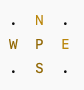



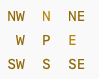

Vecindad (4 - 8)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize
from skimage.measure import label
from matplotlib.patches import Rectangle

# -----------------------------
# 1) Cargar imagen real (astronauta) y convertir a gris
# -----------------------------
img_rgb = data.astronaut()
img = color.rgb2gray(img_rgb)
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

H, W = img.shape

# Escoge un píxel (centro por defecto). Puedes cambiar (r, c).
#r, c = H // 2, W // 2
r , c = 150, 150

# -----------------------------
# 2) Vecindad 4 y 8 de un píxel (r, c)
# -----------------------------
N4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
N8 = [(-1, -1), (-1, 0), (-1, 1),
      (0, -1),           (0, 1),
      (1, -1),  (1, 0),  (1, 1)]

def valid_neighbors(r, c, offsets, H, W):
    coords = []
    for dr, dc in offsets:
        rr, cc = r + dr, c + dc
        if 0 <= rr < H and 0 <= cc < W:
            coords.append((rr, cc))
    return coords

coords4 = valid_neighbors(r, c, N4, H, W)
coords8 = valid_neighbors(r, c, N8, H, W)

print(f"Pixel central (r,c)=({r},{c}) valor={img[r,c]:.4f}")
print("Vecindad-4 (coords, valor):")
for rr, cc in coords4:
    print(f"  ({rr},{cc}) -> {img[rr,cc]:.4f}")
print("Vecindad-8 (coords, valor):")
for rr, cc in coords8:
    print(f"  ({rr},{cc}) -> {img[rr,cc]:.4f}")

# Visualización: zoom 9x9 alrededor del píxel con celdas marcadas
zoom = 5  # radio del recorte (5 -> 11x11 aprox)
r0, r1 = max(0, r-zoom), min(H, r+zoom+1)
c0, c1 = max(0, c-zoom), min(W, c+zoom+1)
patch = img[r0:r1, c0:c1]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Izquierda: mostrar recorte y marcar N4
ax[0].imshow(patch, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Vecindad-4 (N4)")
ax[0].axis("off")

# Centro
ax[0].add_patch(Rectangle((c-c0-0.5, r-r0-0.5), 1, 1, fill=False, linewidth=2))
# Vecinos N4
for rr, cc in coords4:
    if r0 <= rr < r1 and c0 <= cc < c1:
        ax[0].add_patch(Rectangle((cc-c0-0.5, rr-r0-0.5), 1, 1, fill=False, linewidth=2))

# Derecha: marcar N8
ax[1].imshow(patch, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Vecindad-8 (N8)")
ax[1].axis("off")

ax[1].add_patch(Rectangle((c-c0-0.5, r-r0-0.5), 1, 1, fill=False, linewidth=2))
for rr, cc in coords8:
    if r0 <= rr < r1 and c0 <= cc < c1:
        ax[1].add_patch(Rectangle((cc-c0-0.5, rr-r0-0.5), 1, 1, fill=False, linewidth=2))

plt.tight_layout()
plt.show()


Conectividad (4 - 8)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label
from skimage import data, color
from skimage.transform import resize

# ----------------------------------------------------
# 1) Ejemplo pequeño 5x5: diagonal (cambia mucho en 4 vs 8)
# ----------------------------------------------------
A = np.array([
    [1,0,0,0,0],
    [0,1,0,0,0],
    [0,1,1,0,0],
    [0,0,0,1,0],
    [0,0,0,0,1],
], dtype=np.uint8)

L4 = label(A, connectivity=1)  # 4-conectividad en 2D
L8 = label(A, connectivity=2)  # 8-conectividad en 2D

print("Matriz A:\n", A)
print("\n#Objetos con 4-conectividad:", L4.max())
print("#Objetos con 8-conectividad:", L8.max())

plt.figure(figsize=(10,3))
#plt.subplot(1,3,1); plt.imshow(A, cmap="gray"); plt.title("A (binaria)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(L4, cmap="nipy_spectral"); plt.title("Etiquetas (4)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(L8, cmap="nipy_spectral"); plt.title("Etiquetas (8)"); plt.axis("off")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 2) Ejemplo con imagen real (astronauta): binarizar y contar componentes
# ----------------------------------------------------
img = color.rgb2gray(data.astronaut())
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

T = 0.60                       # umbral (ajústalo para ver diferentes resultados)
bw = (img > T).astype(np.uint8)

L4_img = label(bw, connectivity=1)
L8_img = label(bw, connectivity=2)

print("\nImagen astronauta binaria con umbral T =", T)
print("Objetos (4-conectividad):", int(L4_img.max()))
print("Objetos (8-conectividad):", int(L8_img.max()))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Grises"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(bw, cmap="gray"); plt.title(f"Binaria (img > {T})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(L8_img, cmap="nipy_spectral"); plt.title("Componentes (8)"); plt.axis("off")
plt.tight_layout()
plt.show()


**Histograma y ecualización**


*   El histograma de una imagen muestra cuántos píxeles hay en cada nivel de intensidad.
*   La ecualización redistribuye las intensidades para que el histograma quede más “extendido” (más uniforme), con el objetivo de aumentar el contraste.

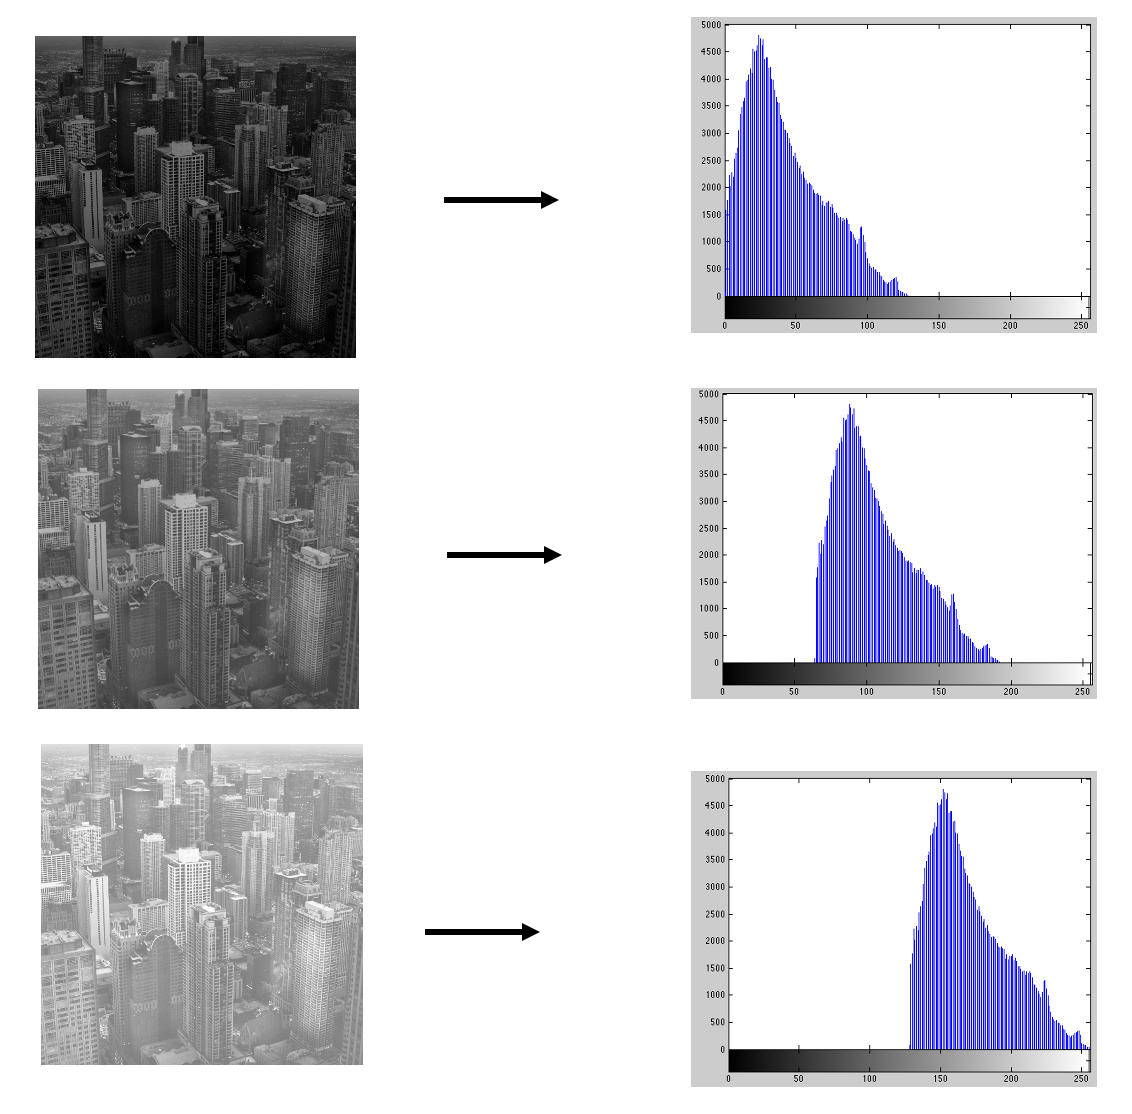



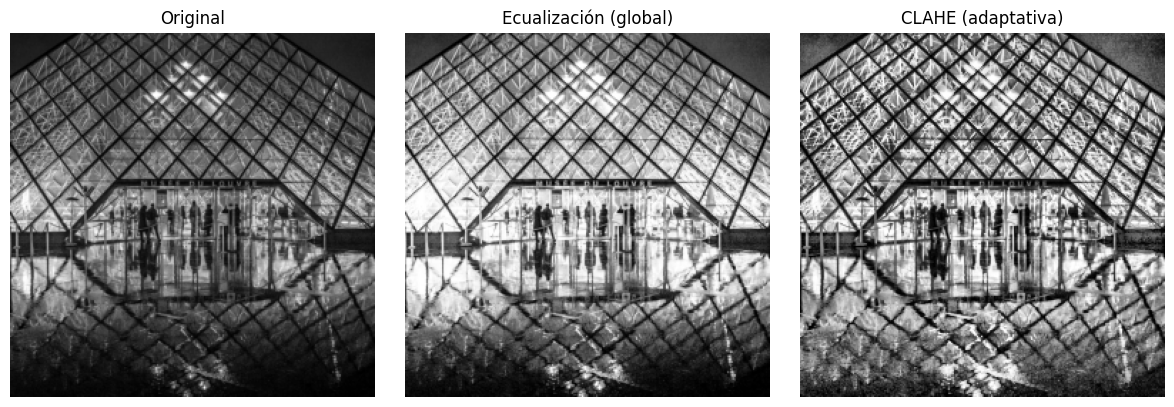

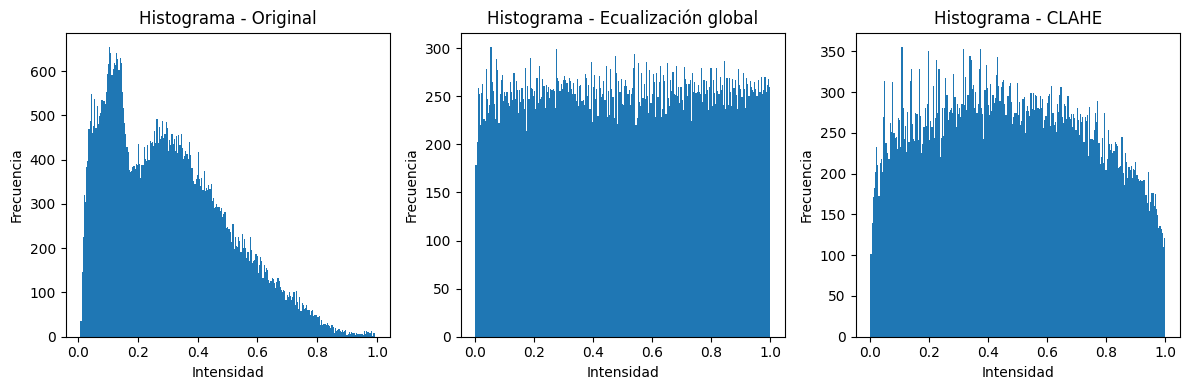

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure
from skimage.transform import resize
import cv2

# 1) Cargar imagen real y pasar a gris
img_rgb = cv2.imread('src/louvre.png')
#img_rgb = data.astronaut()
img = color.rgb2gray(img_rgb)
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)  # valores en [0,1]

# 2) Ecualización global de histograma
img_eq = exposure.equalize_hist(img)  # salida en [0,1]

# (Opcional) CLAHE / ecualización adaptativa (más suave, suele funcionar mejor en muchos casos)
img_clahe = exposure.equalize_adapthist(img, clip_limit=0.03)

# 3) Graficar imágenes
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(img_eq, cmap="gray"); plt.title("Ecualización (global)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(img_clahe, cmap="gray"); plt.title("CLAHE (adaptativa)"); plt.axis("off")
plt.tight_layout()
plt.show()

# 4) Graficar histogramas
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(img.ravel(), bins=256)
plt.title("Histograma - Original")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")

plt.subplot(1, 3, 2)
plt.hist(img_eq.ravel(), bins=256)
plt.title("Histograma - Ecualización global")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")

plt.subplot(1, 3, 3)
plt.hist(img_clahe.ravel(), bins=256)
plt.title("Histograma - CLAHE")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


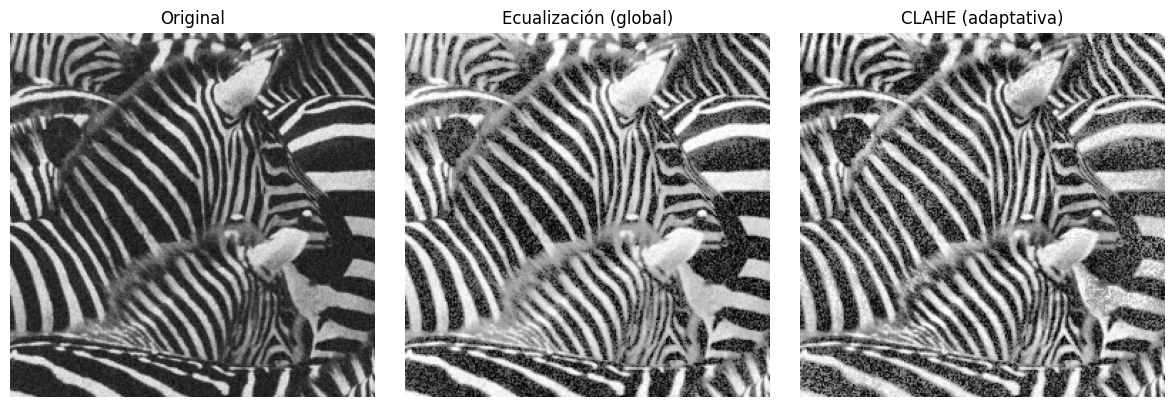

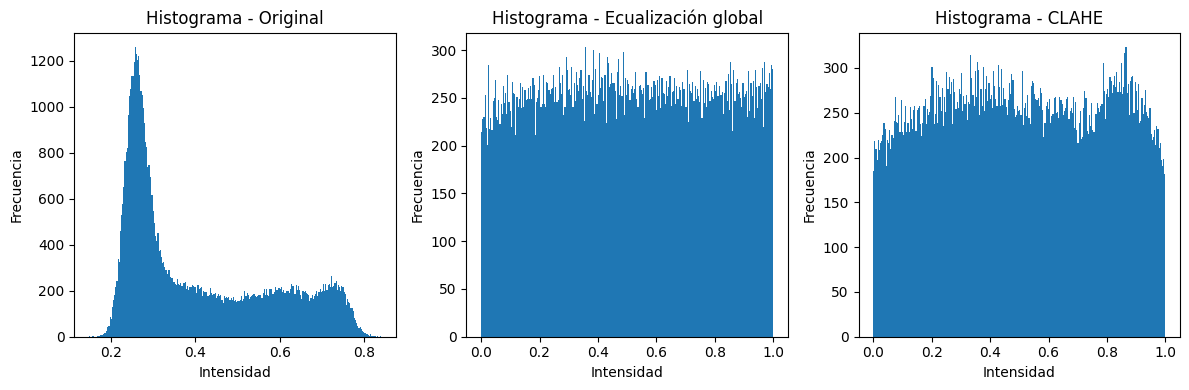

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure
from skimage.transform import resize
import cv2

# 1) Cargar imagen real y pasar a gris
img_rgb = cv2.imread('src/zebra_noise.png')
#img_rgb = data.astronaut()
img = color.rgb2gray(img_rgb)
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)  # valores en [0,1]

# 2) Ecualización global de histograma
img_eq = exposure.equalize_hist(img)  # salida en [0,1]

# (Opcional) CLAHE / ecualización adaptativa (más suave, suele funcionar mejor en muchos casos)
img_clahe = exposure.equalize_adapthist(img, clip_limit=0.03)

# 3) Graficar imágenes
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(img_eq, cmap="gray"); plt.title("Ecualización (global)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(img_clahe, cmap="gray"); plt.title("CLAHE (adaptativa)"); plt.axis("off")
plt.tight_layout()
plt.show()

# 4) Graficar histogramas
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(img.ravel(), bins=256)
plt.title("Histograma - Original")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")

plt.subplot(1, 3, 2)
plt.hist(img_eq.ravel(), bins=256)
plt.title("Histograma - Ecualización global")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")

plt.subplot(1, 3, 3)
plt.hist(img_clahe.ravel(), bins=256)
plt.title("Histograma - CLAHE")
plt.xlabel("Intensidad"); plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Introducción a filtros y convoluciones**

La convolución es una operación matemática que combina una imagen con un
kernel o máscara para producir una nueva imagen filtrada.


Un filtro de suavizado común es el filtro de media, que reemplaza cada píxel por
el promedio de sus vecinos, reduciendo así las variaciones abruptas en la imagen.


*   **Filtro de Media:** Calcula el promedio de los píxeles en la vecindad y
lo asigna al píxel central. Es eficaz para ruido aleatorio pero puede
difuminar bordes.
*   **Filtro de Mediana:** Reemplaza el valor del píxel central por la mediana
de los valores en la vecindad. Es especialmente efectivo para eliminar
ruido impulsivo (sal y pimienta)


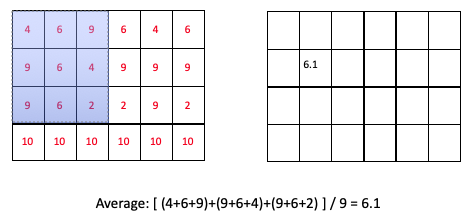


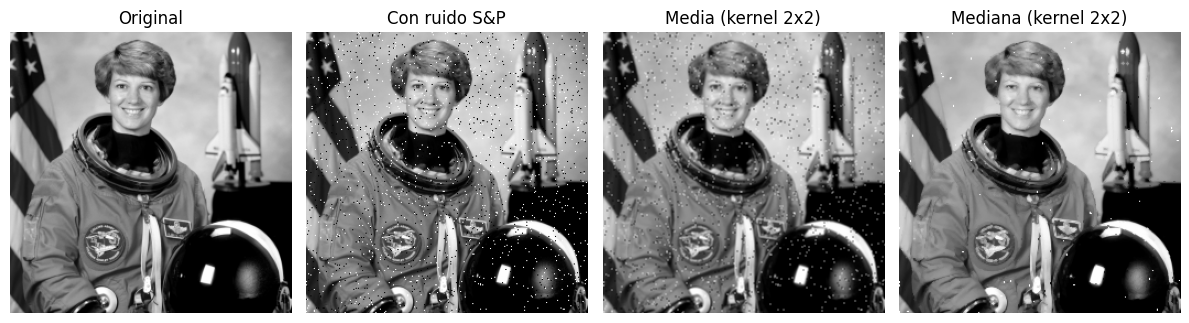

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, util
from skimage.transform import resize
from scipy.ndimage import uniform_filter, median_filter

# ------------------------------------------------------------
# 1) Cargar imagen real (astronauta) y preparar en escala de grises
# ------------------------------------------------------------
img = color.rgb2gray(data.astronaut())
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

# (Opcional) añadir ruido sal y pimienta para ver mejor la diferencia
img_sp = util.random_noise(img, mode="s&p", amount=0.03).astype(np.float32)

# ------------------------------------------------------------
# 2) Filtro de MEDIA (mean filter)
# ------------------------------------------------------------
# Idea: reemplaza cada píxel por el promedio de su vecindad (kernel).
# Esto suaviza ruido, pero también difumina bordes.
k = 2  # tamaño del kernel (5x5)
img_mean = uniform_filter(img_sp, size=k)

# ------------------------------------------------------------
# 3) Filtro de MEDIANA (median filter)
# ------------------------------------------------------------
# Idea: reemplaza cada píxel por la mediana de su vecindad.
# Es muy bueno para ruido "sal y pimienta" porque elimina outliers
# sin difuminar tanto los bordes como la media.
img_median = median_filter(img_sp, size=k)

# ------------------------------------------------------------
# 4) Visualización
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_sp, cmap="gray", vmin=0, vmax=1)
plt.title("Con ruido S&P")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_mean, cmap="gray", vmin=0, vmax=1)
plt.title(f"Media (kernel {k}x{k})")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_median, cmap="gray", vmin=0, vmax=1)
plt.title(f"Mediana (kernel {k}x{k})")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
b=[3,5,6,7,8,9,50,20,4,1,2,100,2000]
print(sum(b)/len(b))

b=[3,5,6,7,8,9,50,20,4,1,2,100,2000]
b.sort()
print(b[len(b)//2])


**Realce mediante operadores aritméticos**


*   Suma: Incrementa la intensidad global de la imagen, útil para aclarar
imágenes oscuras.
*   Resta: Puede utilizarse para resaltar diferencias entre imágenes.
*   Multiplicación: Aumenta o disminuye el contraste dependiendo del
factor utilizado.






In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# 1) Cargar 2 imágenes reales y convertir a gris
img1 = color.rgb2gray(data.astronaut())
img2 = data.camera() / 255.0  # ya es gris en uint8; lo llevamos a [0,1]

# 2) Asegurar mismo tamaño
img1 = resize(img1, (256, 256), anti_aliasing=True).astype(np.float32)
img2 = resize(img2, (256, 256), anti_aliasing=True).astype(np.float32)

# -----------------------------------------
# Operaciones píxel a píxel
# -----------------------------------------

# A) Suma (brillo/mezcla)
sum_img = np.clip(img1 + img2, 0, 1)

# Mezcla controlada (blend): alpha*img1 + (1-alpha)*img2
alpha = 0.6
blend_img = np.clip(alpha * img1 + (1 - alpha) * img2, 0, 1)

# B) Resta (diferencia)
sub_img_1_2 = np.clip(img1 - img2, 0, 1)           # conserva solo lo positivo
sub_img_2_1 = np.clip(img2 - img1, 0, 1)

# Diferencia absoluta (muy usada): resalta cambios sin signo
abs_diff = np.abs(img1 - img2)

# C) Multiplicación (modulación / máscara)
mul_img = np.clip(img1 * img2, 0, 1)

# -----------------------------------------
# Visualización
# -----------------------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1); plt.imshow(img1, cmap="gray"); plt.title("Imagen 1 (astronaut)"); plt.axis("off")
plt.subplot(2, 4, 2); plt.imshow(img2, cmap="gray"); plt.title("Imagen 2 (camera)"); plt.axis("off")

plt.subplot(2, 4, 3); plt.imshow(sum_img, cmap="gray"); plt.title("Suma: img1 + img2"); plt.axis("off")
#plt.subplot(2, 4, 4); plt.imshow(blend_img, cmap="gray"); plt.title(f"Mezcla: {alpha}*img1 + {1-alpha}*img2"); plt.axis("off")


#plt.subplot(2, 4, 8); plt.imshow(mul_img, cmap="gray"); plt.title("Multiplicación: img1 * img2"); plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize
from skimage.draw import disk

# -----------------------------
# 1) Imagen base real
# -----------------------------
base = color.rgb2gray(data.astronaut())
base = resize(base, (256, 256), anti_aliasing=True).astype(np.float32)

# -----------------------------
# 2) Crear una secuencia de frames con un objeto que se mueve (cambio en el tiempo)
# -----------------------------
T = 8  # número de frames
frames = []

for t in range(T):
    frame = base.copy()

    # objeto "nuevo" que se mueve: un círculo brillante
    rr, cc = disk((60 + 18*t, 40 + 20*t), radius=10, shape=frame.shape)
    frame[rr, cc] = 1.0  # brillante

    # (opcional) pequeña variación global de brillo para simular condiciones reales
    frame = np.clip(frame + 0.02*np.sin(t), 0, 1)

    frames.append(frame)

frames = np.stack(frames, axis=0)  # (T, H, W)

# -----------------------------
# 3) Resta entre frames consecutivos (diferencia absoluta)
# -----------------------------
diffs = np.abs(frames[1:] - frames[:-1])  # (T-1, H, W)

# Umbral para "cambio significativo" (ajústalo si quieres)
th = 0.15
motion_masks = (diffs > th).astype(np.uint8)

# Máscara acumulada de movimiento en toda la secuencia
motion_any = (motion_masks.sum(axis=0) > 0).astype(np.uint8)

# -----------------------------
# 4) Visualización: mostrar algunos pasos (frame t-1, frame t, diff, máscara)
# -----------------------------
pairs_to_show = [1, 3, 6]  # índices de frame t (muestra cambios en distintos tiempos)

plt.figure(figsize=(12, 9))
row = 1
for idx, t in enumerate(pairs_to_show):
    prev = frames[t-1]
    curr = frames[t]
    diff = diffs[t-1]
    mask = motion_masks[t-1]

    plt.subplot(len(pairs_to_show), 4, row); plt.imshow(prev, cmap="gray", vmin=0, vmax=1)
    plt.title(f"Frame t={t-1}"); plt.axis("off")

    plt.subplot(len(pairs_to_show), 4, row+1); plt.imshow(curr, cmap="gray", vmin=0, vmax=1)
    plt.title(f"Frame t={t}"); plt.axis("off")

    plt.subplot(len(pairs_to_show), 4, row+2); plt.imshow(diff, cmap="gray")
    plt.title("|I_t - I_{t-1}|"); plt.axis("off")

    plt.subplot(len(pairs_to_show), 4, row+3); plt.imshow(mask, cmap="gray")
    plt.title(f"Máscara (diff > {th})"); plt.axis("off")

    row += 4

plt.tight_layout()
plt.show()

# Mostrar máscara acumulada (dónde hubo movimiento en toda la secuencia)
plt.figure(figsize=(5, 5))
plt.imshow(motion_any, cmap="gray")
plt.title("Zonas que cambiaron (cualquier t)")
plt.axis("off")
plt.tight_layout()
plt.show()


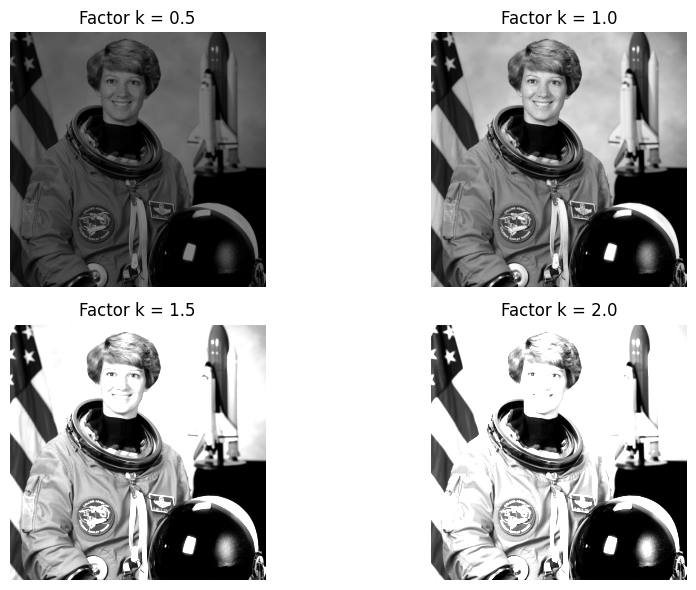

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# 1) Imagen real en gris [0,1]
img = color.rgb2gray(data.astronaut())
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

# 2) Factores (oscurecer y aclarar)
factors = [0.5, 1.0, 1.5, 2.0]

# 3) Aplicar multiplicación y recortar (clip)
imgs_scaled = [np.clip(img * k, 0, 1) for k in factors]

# 4) Mostrar resultados
plt.figure(figsize=(10, 6))
for i, k in enumerate(factors, start=1):
    plt.subplot(2, 2, i)
    plt.imshow(imgs_scaled[i-1], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Factor k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Técnicas avanzadas de suavizado y filtrado**


*   **Filtro Gaussiano:** reemplaza cada píxel por un promedio ponderado de sus vecinos usando una “campana” gaussiana: los píxeles más cercanos pesan más. Suaviza de forma uniforme y suele difuminar bordes, pero generalmente menos “brusco” que una media simple. A mayor sigma, más borroso.
*   **Filtro Bilateral:** suaviza, pero decide cuánto promediar usando dos criterios:
Distancia espacial (cercanía)
Diferencia de intensidad (similitud)
Si un vecino tiene intensidad muy distinta (posible borde), pesa menos. Reducir ruido manteniendo bordes (mejor que gaussiano en ese sentido)

*   **Wavelets:** separa la imagen en componentes de frecuencia: Bajas frecuencias: estructura general (formas suaves).
Altas frecuencias: detalles finos… y también gran parte del ruido. Eliminar ruido actuando principalmente sobre las altas frecuencias (por ejemplo, “encogiendo” coeficientes pequeños). No filtra por vecindario directo como los anteriores; filtra por frecuencia/escala, lo cual puede preservar mejor ciertos detalles.






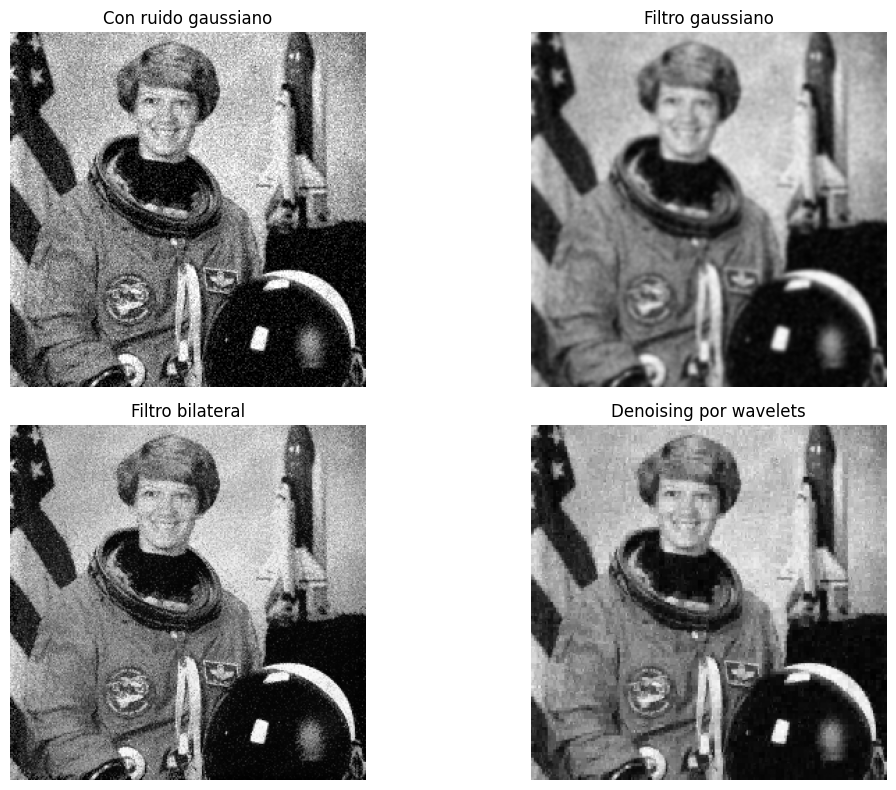

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, util
from skimage.transform import resize
from skimage.filters import gaussian
from skimage.restoration import denoise_bilateral, denoise_wavelet

# 1) Imagen real
img = color.rgb2gray(data.astronaut())
img = resize(img, (256, 256), anti_aliasing=True).astype(np.float32)

# 2) Agregar ruido gaussiano para que se note el efecto (simulación)
img_noisy = util.random_noise(img, mode="gaussian", var=0.01).astype(np.float32)

# 3) Filtros
# Gaussiano
img_gauss = gaussian(img_noisy, sigma=1.2)

# Bilateral (edge-preserving)
img_bilat = denoise_bilateral(
    img_noisy,
    sigma_color=0.08,     # sensibilidad a diferencias de intensidad
    sigma_spatial=3,      # vecindario espacial
    channel_axis=None
)

# Wavelet denoising (actúa por frecuencia/escala)
img_wave = denoise_wavelet(
    img_noisy,
    channel_axis=None,
    rescale_sigma=True
)

# 4) Visualización
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_noisy, cmap="gray", vmin=0, vmax=1)
plt.title("Con ruido gaussiano")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_gauss, cmap="gray", vmin=0, vmax=1)
plt.title("Filtro gaussiano")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_bilat, cmap="gray", vmin=0, vmax=1)
plt.title("Filtro bilateral")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_wave, cmap="gray", vmin=0, vmax=1)
plt.title("Denoising por wavelets")
plt.axis("off")

plt.tight_layout()
plt.show()
